In [1]:
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
import pandas as pd
import pygmt

In [ ]:
dls = pd.read_csv('..\\..\\created_data\\botlowsed.csv', sep=',', header=None, 
                 names=['long', 'lat', 'z'], skiprows=1)
print(dls.head())

dms = pd.read_csv('..\\..\\created_data\\botmidsed.csv', sep=',', header=None, 
                 names=['long', 'lat', 'z'], skiprows=1)
print(dms.head())

dus = pd.read_csv('..\\..\\created_data\\botupsed.csv', sep=',', header=None, 
                 names=['long', 'lat', 'z'], skiprows=1)
print(dus.head())

    long   lat     z
0 -133.0  38.0 -5.08
1 -133.0  39.0 -4.95
2 -133.0  40.0 -4.73
3 -133.0  41.0 -3.91
4 -133.0  42.0 -3.84
    long   lat     z
0 -133.0  38.0 -5.08
1 -133.0  39.0 -4.95
2 -133.0  40.0 -4.73
3 -133.0  41.0 -3.91
4 -133.0  42.0 -3.84
    long   lat     z
0 -133.0  38.0 -5.08
1 -133.0  39.0 -4.95
2 -133.0  40.0 -4.73
3 -133.0  41.0 -3.91
4 -133.0  42.0 -3.84


making a dictionary of each latitude with its corrsp long and z

*for lat in df['lat'].unique()* get all the unique lat values to loop through each one once

*blc[lat] = df[df['lat'] == lat][['long','z']]* filters the dataframe to only rows where lat equals the current lat value (38 = 38) and then keeps only long and z

In [ ]:
bls = {}
for lat in dls['lat'].unique():
    bls[lat] = dls[dls['lat'] == lat][['long','z']] 

bms= {}
for lat in dms['lat'].unique(): 
    bms[lat] = dms[dms['lat'] == lat][['long','z']] 

bus = {}
for lat in dus['lat'].unique():   
    bus[lat] = dus[dus['lat'] == lat][['long','z']]  

now creating a new dataframe (all) made of the long, and then each z for that long at that lat

In [ ]:
all = {}
for lat in bls.keys():
    all[lat]=pd.DataFrame({  # creating a new dataframe
        'long':bls[lat]['long'].values,  # grabs the longitude values for that lat
        'z_low':bls[lat]['z'].values,  # grabbing z and so forth
        'z_mid':bms[lat]['z'].values,
        'z_up':bus[lat]['z'].values})

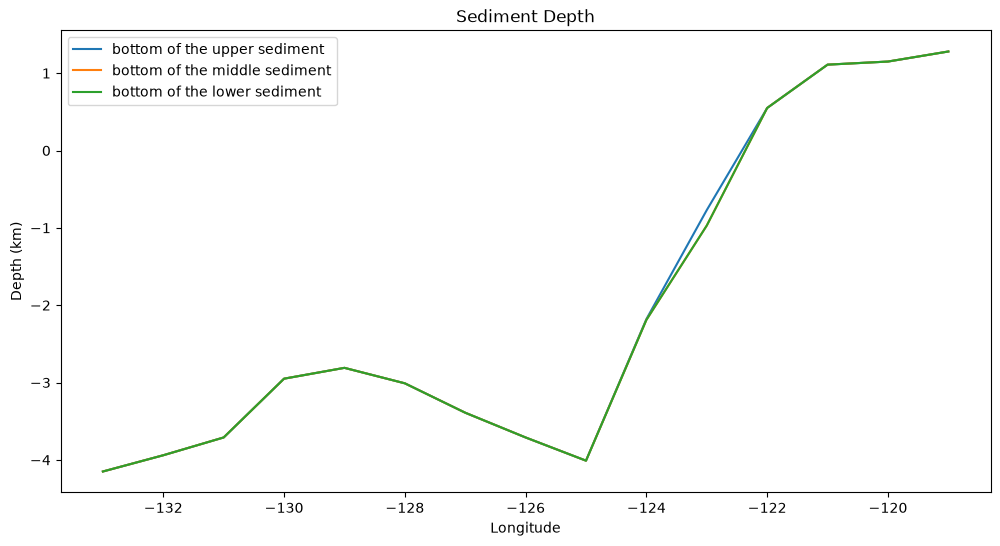

In [6]:
lat = 45

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(all[lat]['long'], all[lat]['z_up'], label='bottom of the upper sediment')
ax.plot(all[lat]['long'], all[lat]['z_mid'], label='bottom of the middle sediment')
ax.plot(all[lat]['long'], all[lat]['z_low'], label='bottom of the lower sediment')

ax.set_xlabel('Longitude')
ax.set_ylabel('Depth (km)')
ax.set_title('Sediment Depth')
ax.legend()
plt.show()